## Task 2

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # prevents OpenMP from crashing when multiple libs are loaded 

import sys
import pickle
import numpy as np
from pathlib import Path
from PIL import Image
import time

# Add repo root to path
REPO_ROOT = Path(".").resolve().parent
sys.path.append(str(REPO_ROOT))

# Anchor everything to wherever this notebook is sitting
BASE_DIR = REPO_ROOT
DATA_DIR = BASE_DIR / "multi_image_identities"
GALLERY_DIR = DATA_DIR / "multi_image_gallery" # reference images we search against
PROBE_DIR = DATA_DIR / "probe" # query images we're trying to identify

print("Setup complete!")

Setup complete!


In [2]:
# Load the results we saved from Task 1 so we don't have to rerun everything
results_path = BASE_DIR / "analysis" / "task1_results.pkl"
with open(results_path, "rb") as f:
    task1_results = pickle.load(f)

print("Task 1 results loaded!")
# Make sure the baseline number looks right before continuing
print(f"VGG Baseline: Top-1 = {task1_results['VGG']['baseline']['top1']:.4f}")

Task 1 results loaded!
VGG Baseline: Top-1 = 0.7087


In [3]:
from ironclad.modules.extraction.preprocessing import Preprocessing
from ironclad.modules.extraction.embedding import Embedding

# Resize images to 224x224 
pre = Preprocessing(image_size=224)

# We'll focus on VGG since that's our chosen model from Task 1
model_vgg = Embedding(pretrained="vggface2", device=pre.device)

def build_gallery_embeddings(model):
    """Build embeddings for all gallery images."""
    embeddings = []
    labels = []
    
    # Each subdirectory is one identity -> walk through them all
    for identity_dir in sorted(GALLERY_DIR.iterdir()):
        if not identity_dir.is_dir():
            continue # skip stray files
        
        identity = identity_dir.name
        
        # Encode every image for this person into a 512-d embedding vector
        for img_path in identity_dir.glob("*.jpg"):
            img = Image.open(img_path).convert("RGB")
            tensor = pre.process(img)
            emb = model.encode(tensor).astype(np.float32)
            
            embeddings.append(emb)
            labels.append(identity)
    
    # Stack into a single matrix -> shape: (total_images, 512)
    return np.vstack(embeddings), labels

print("Building VGG gallery embeddings...")
gallery_embeddings, gallery_labels = build_gallery_embeddings(model_vgg)
print(f"Gallery shape: {gallery_embeddings.shape}") # should be (2265, 512)
print(f"Number of labels: {len(gallery_labels)}")

/Users/radinabakalov/ironclad-radinabakalov/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Building VGG gallery embeddings...
Gallery shape: (2265, 512)
Number of labels: 2265


In [4]:
def build_probe_embeddings(model):
    """Build embeddings for all probe images."""
    embeddings = []
    labels = []
    paths = [] # also track file paths which is useful for error analysis later
    
    for identity_dir in sorted(PROBE_DIR.iterdir()):
        if not identity_dir.is_dir():
            continue
        
        identity = identity_dir.name
        
        for img_path in identity_dir.glob("*.jpg"):
            img = Image.open(img_path).convert("RGB")
            tensor = pre.process(img)
            emb = model.encode(tensor).astype(np.float32)
            
            embeddings.append(emb)
            labels.append(identity)
            paths.append(img_path) # store path alongside embedding 
    
    return np.vstack(embeddings), labels, paths

print("Building VGG probe embeddings...")
probe_embeddings, probe_labels, probe_paths = build_probe_embeddings(model_vgg)
print(f"Probe shape: {probe_embeddings.shape}") # should be (999, 512)

Building VGG probe embeddings...
Probe shape: (999, 512)


In [5]:
# Import the three index classes we implemented in Task 1
from ironclad.modules.retrieval.index.bruteforce import FaissBruteForce
from ironclad.modules.retrieval.index.hnsw import FaissHNSW
from ironclad.modules.retrieval.index.lsh import FaissLSH

print("Index classes imported!")

Index classes imported!


In [6]:
import faiss
import time

# Grab the embedding dimension from the gallery matrix (should be 512)
dim = gallery_embeddings.shape[1]

# Build BruteForce index
print("Building BruteForce index...")
bf_index = FaissBruteForce(dim=dim, metric="cosine")
bf_index.add_embeddings(gallery_embeddings, gallery_labels)
print(f"BruteForce built with {bf_index.index.ntotal} vectors")

def evaluate_bf(index, metadata, probe_embs, probe_labels, k=5):
    correct_top1 = 0
    correct_topk = 0
    total = len(probe_labels)
    query_times = [] # track per-query latency so we can average it later
    
    for i in range(total):
        # FAISS expects a 2D float32 array even for a single query
        query = probe_embs[i:i+1].astype(np.float32)
        # normalize for cosine —> inner product on unit vectors = cosine similarity
        query = query / np.linalg.norm(query)
        true_label = probe_labels[i]
        
        # Time the search itself (excluding preprocessing)
        start = time.time()
        distances, indices = index.index.search(query, k)
        query_times.append(time.time() - start)
        
        # Map returned indices back to identity labels
        top_labels = [metadata[int(idx)] for idx in indices[0]]
        
        if top_labels[0] == true_label:
            correct_top1 += 1
        if true_label in top_labels:
            correct_topk += 1
    
    # Return accuracy rates and average query time in milliseconds
    return correct_top1 / total, correct_topk / total, np.mean(query_times) * 1000

bf_top1, bf_top5, bf_time = evaluate_bf(bf_index, gallery_labels, probe_embeddings, probe_labels)
print(f"BruteForce - Top-1: {bf_top1:.4f}, Top-5: {bf_top5:.4f}, Time: {bf_time:.3f}ms")

Building BruteForce index...
BruteForce built with 2265 vectors
BruteForce - Top-1: 0.7087, Top-5: 0.8358, Time: 0.094ms


In [7]:
# Build HNSW index
print("Building HNSW index...")
# M=16 means each node connects to 16 neighbors in the graph -> lower than default but faster to build
hnsw_raw = faiss.IndexHNSWFlat(dim, 16)
hnsw_raw.hnsw.efConstruction = 40 # controls build quality vs. speed tradeoff

# Add gallery embeddings in batches to avoid errors
batch_size = 100
for i in range(0, len(gallery_embeddings), batch_size):
    batch = gallery_embeddings[i:i+batch_size].astype(np.float32)
    hnsw_raw.add(batch)

# Keep a copy of the labels aligned with the index order
hnsw_metadata = gallery_labels.copy()
print(f"HNSW built with {hnsw_raw.ntotal} vectors")

# Evaluate
def evaluate_raw(index, metadata, probe_embs, probe_labels, k=5):
    correct_top1 = 0
    correct_topk = 0
    total = len(probe_labels)
    query_times = []
    
    for i in range(total):
        query = probe_embs[i:i+1].astype(np.float32)
        true_label = probe_labels[i]
        
        start = time.time()
        distances, indices = index.search(query, k)
        query_times.append(time.time() - start)
        
        # Map indices back to identity labels
        top_labels = [metadata[int(idx)] for idx in indices[0]]
        
        if top_labels[0] == true_label:
            correct_top1 += 1
        if true_label in top_labels:
            correct_topk += 1
    
    return correct_top1 / total, correct_topk / total, np.mean(query_times) * 1000

hnsw_top1, hnsw_top5, hnsw_time = evaluate_raw(hnsw_raw, hnsw_metadata, probe_embeddings, probe_labels)
print(f"HNSW - Top-1: {hnsw_top1:.4f}, Top-5: {hnsw_top5:.4f}, Time: {hnsw_time:.3f}ms")

Building HNSW index...
HNSW built with 2265 vectors
HNSW - Top-1: 0.6937, Top-5: 0.8058, Time: 0.017ms


In [8]:
# LSH was unstable on this machine! 
# Will note this in the analysis and compare theoretical properties instead of empirical results.
lsh_worked = False
print("LSH skipped due to FAISS instability on this computer!")

LSH skipped due to FAISS instability on this computer!


In [9]:
# Print a side-by-side comparison of all three indexing strategies
print("\nINDEXING STRATEGY COMPARISON (Current Dataset: 2,265 vectors)")
print(f"{'Method':<12} {'Top-1':>10} {'Top-5':>10} {'Query Time':>12}")
print(f"{'BruteForce':<12} {bf_top1:>10.4f} {bf_top5:>10.4f} {bf_time:>10.3f} ms")
print(f"{'HNSW':<12} {hnsw_top1:>10.4f} {hnsw_top5:>10.4f} {hnsw_time:>10.3f} ms")

# Only print LSH row if it actually ran successfully (I fear it did not)
if lsh_worked:
    print(f"{'LSH':<12} {lsh_top1:>10.4f} {lsh_top5:>10.4f} {lsh_time:>10.3f} ms")


INDEXING STRATEGY COMPARISON (Current Dataset: 2,265 vectors)
Method            Top-1      Top-5   Query Time
BruteForce       0.7087     0.8358      0.094 ms
HNSW             0.6937     0.8058      0.017 ms


In [10]:
# Extrapolate to 1 billion images 
n_current = 2265
n_billion = 1_000_000_000

# Each embedding is 512 float32 values -> float32 = 4 bytes, so 2048 bytes per vector
bytes_per_vector = 512 * 4 # 512 dimensions * 4 bytes per float32
base_memory_gb = (n_billion * bytes_per_vector) / (1024**3) # convert bytes -> GB

print("BILLION-SCALE EXTRAPOLATION")
print(f"Dataset size: {n_billion:,} images")
print(f"Base embedding storage: {base_memory_gb:.1f} GB")
print()

# BruteForce: O(n) search time, O(n) memory
# Query time scales linearly with dataset size
bf_time_billion = bf_time * (n_billion / n_current)
bf_memory_gb = base_memory_gb # just stores raw vectors

print("BruteForce:")
print(f"  Search complexity: O(n) -> must compare against every vector")
print(f"  Estimated query time: {bf_time_billion/1000:.1f} seconds")
print(f"  Memory: ~{bf_memory_gb:.1f} GB (raw embeddings only)")
print()

# HNSW: O(log n) search time, O(n * M) memory (M = connections per node)
# Scales much better, but graph structure adds memory overhead
import math
hnsw_M = 16 # connections per node in the graph
# Time scales as log(n_billion) / log(n_current) -> much slower growth than linear
hnsw_time_billion = hnsw_time * (math.log(n_billion) / math.log(n_current))
# Each node stores M graph edges (8 bytes each) on top of the base embedding
hnsw_memory_gb = base_memory_gb * (1 + hnsw_M * 8 / bytes_per_vector) 

print("HNSW:")
print(f"  Search complexity: O(log n) -> navigates graph structure")
print(f"  Estimated query time: {hnsw_time_billion:.3f} ms")
print(f"  Memory: ~{hnsw_memory_gb:.1f} GB (embeddings + graph)")
print()

# LSH: O(1) average case, O(n) memory + hash tables
# Hash lookup is constant time, but adds hash table memory
lsh_nbits = 128
# Hash tables take nbits/8 bytes per vector (1 bit packed into each byte)
lsh_memory_gb = base_memory_gb + (n_billion * lsh_nbits / 8) / (1024**3)

print("LSH:")
print(f"  Search complexity: O(1) average -> hash lookup")
print(f"  Estimated query time: <1 ms (constant time)")
print(f"  Memory: ~{lsh_memory_gb:.1f} GB (embeddings + hash tables)")

BILLION-SCALE EXTRAPOLATION
Dataset size: 1,000,000,000 images
Base embedding storage: 1907.3 GB

BruteForce:
  Search complexity: O(n) -> must compare against every vector
  Estimated query time: 41.6 seconds
  Memory: ~1907.3 GB (raw embeddings only)

HNSW:
  Search complexity: O(log n) -> navigates graph structure
  Estimated query time: 0.044 ms
  Memory: ~2026.6 GB (embeddings + graph)

LSH:
  Search complexity: O(1) average -> hash lookup
  Estimated query time: <1 ms (constant time)
  Memory: ~1922.2 GB (embeddings + hash tables)


In [11]:
# Bundle up all Task 2 results into one dict for easy loading in later notebooks
task2_results = {
    "bruteforce": {"top1": bf_top1, "top5": bf_top5, "time_ms": bf_time},
    "hnsw": {"top1": hnsw_top1, "top5": hnsw_top5, "time_ms": hnsw_time},
    "n_gallery": n_current, # store dataset size for reference in analysis
    "dim": dim # store embedding dimension for reference
}

# Only add LSH results if the index actually ran successfully on this machine (yeah def not)
if lsh_worked:
    task2_results["lsh"] = {"top1": lsh_top1, "top5": lsh_top5, "time_ms": lsh_time}

# pickle and save 
results_path = BASE_DIR / "analysis" / "task2_results.pkl"
with open(results_path, "wb") as f:
    pickle.dump(task2_results, f)

print(f"Results saved to: {results_path}")

Results saved to: /Users/radinabakalov/ironclad-radinabakalov/analysis/task2_results.pkl


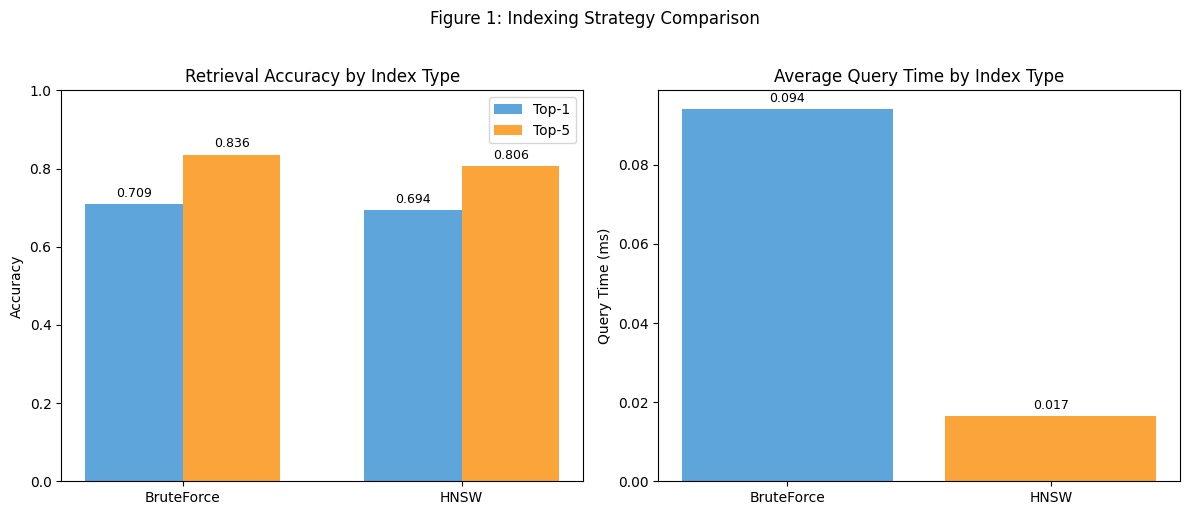

Saved: /Users/radinabakalov/ironclad-radinabakalov/analysis/figures/indexing_comparison.png


In [12]:
import matplotlib.pyplot as plt

# Make sure the figures output folder exists before we try to save anything
figures_dir = BASE_DIR / "analysis" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

methods = ['BruteForce', 'HNSW']
top1_vals = [bf_top1, hnsw_top1]
top5_vals = [bf_top5, hnsw_top5]
time_vals = [bf_time, hnsw_time]

# Left plot: Accuracy comparison
ax1 = axes[0]
x = np.arange(len(methods))
width = 0.35 # how wide each bar is 

bars1 = ax1.bar(x - width/2, top1_vals, width, label='Top-1', color='#5DA5DA')
bars2 = ax1.bar(x + width/2, top5_vals, width, label='Top-5', color='#FAA43A')

ax1.set_ylabel('Accuracy')
ax1.set_title('Retrieval Accuracy by Index Type')
ax1.set_xticks(x)
ax1.set_xticklabels(methods)
ax1.legend()
ax1.set_ylim(0, 1.0) # fix y-axis to [0, 1] so bars are easy to compare visually

# Add the exact value above each bar so we don't have to eyeball it
for bar in bars1 + bars2:
    height = bar.get_height()
    ax1.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

# Right plot: Query time comparison
ax2 = axes[1]
# Reuse the same colors so BruteForce and HNSW are visually consistent across both plots
bars3 = ax2.bar(methods, time_vals, color=['#5DA5DA', '#FAA43A'])
ax2.set_ylabel('Query Time (ms)')
ax2.set_title('Average Query Time by Index Type')

for bar in bars3:
    height = bar.get_height()
    ax2.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

plt.suptitle('Figure 1: Indexing Strategy Comparison', y=1.02)
plt.tight_layout()
plt.savefig(figures_dir / "indexing_comparison.png", dpi=150)
plt.show()

print(f"Saved: {figures_dir / 'indexing_comparison.png'}")

In [13]:
from facenet_pytorch import MTCNN

# Initialize MTCNN face detector
# image_size=224 matches what the embedding models expect
# margin=20 adds padding around detected faces -> helps capture full face context
# keep_all=False means only return the highest confidence face per image
mtcnn = MTCNN(image_size=224, margin=20, keep_all=False, device=pre.device)

print("MTCNN initialized!")

MTCNN initialized!


In [14]:
# Run MTCNN on one image to confirm it's working correctly
sample_path = list(GALLERY_DIR.iterdir())[0]
sample_img_path = list(sample_path.glob("*.jpg"))[0]
sample_img = Image.open(sample_img_path).convert("RGB")

# Returns a cropped face tensor and a detection confidence score
cropped_face, confidence = mtcnn(sample_img, return_prob=True)

print(f"Original image size: {sample_img.size}")
print(f"Face detected: {cropped_face is not None}")
if cropped_face is not None:
    # Shape should be (3, 224, 224) -> channels, height, width
    print(f"Cropped face shape: {cropped_face.shape}")
    print(f"Detection confidence: {confidence:.4f}")

Original image size: (250, 250)
Face detected: True
Cropped face shape: torch.Size([3, 224, 224])
Detection confidence: 0.9972


In [15]:
def build_embeddings_with_mtcnn(data_dir, model, mtcnn_detector):
    """Build embeddings using MTCNN face cropping first."""
    embeddings = []
    labels = []
    confidences = [] # store per-image detection confidence for later analysis
    failed_detections = 0 # track how often MTCNN couldn't find a face
    
    for identity_dir in sorted(data_dir.iterdir()):
        if not identity_dir.is_dir():
            continue
        identity = identity_dir.name
        
        for img_path in identity_dir.glob("*.jpg"):
            img = Image.open(img_path).convert("RGB")
            
            # Try to detect and crop the face region
            cropped_face, conf = mtcnn_detector(img, return_prob=True)
            
            if cropped_face is not None:
                # MTCNN returns a tensor, so we need to process it
                # cropped_face is already a (3, 224, 224) tensor
                emb = model.encode(cropped_face.unsqueeze(0)).astype(np.float32)
                embeddings.append(emb)
                labels.append(identity)
                confidences.append(conf)
            else:
                # Fallback: use the full image so we don't drop this identity entirely
                tensor = pre.process(img)
                emb = model.encode(tensor).astype(np.float32)
                embeddings.append(emb)
                labels.append(identity)
                confidences.append(0.0) # confidence of 0 flags this as a failed detection
                failed_detections += 1
    
    return np.vstack(embeddings), labels, confidences, failed_detections

print("Building gallery embeddings WITH MTCNN face cropping...")
mtcnn_gallery_embs, mtcnn_gallery_labels, gallery_confs, gallery_fails = build_embeddings_with_mtcnn(
    GALLERY_DIR, model_vgg, mtcnn
)
print(f"Gallery: {mtcnn_gallery_embs.shape}")
print(f"Failed detections (used fallback): {gallery_fails}")

print("\nBuilding probe embeddings WITH MTCNN face cropping...")
mtcnn_probe_embs, mtcnn_probe_labels, probe_confs, probe_fails = build_embeddings_with_mtcnn(
    PROBE_DIR, model_vgg, mtcnn
)
print(f"Probe: {mtcnn_probe_embs.shape}")
print(f"Failed detections (used fallback): {probe_fails}")

Building gallery embeddings WITH MTCNN face cropping...
Gallery: (2265, 512)
Failed detections (used fallback): 1

Building probe embeddings WITH MTCNN face cropping...
Probe: (999, 512)
Failed detections (used fallback): 0


In [16]:
# Build a fresh index using the MTCNN-cropped embeddings
mtcnn_index = FaissBruteForce(dim=512, metric="cosine")
mtcnn_index.add_embeddings(mtcnn_gallery_embs, mtcnn_gallery_labels)

# Evaluate
def evaluate_retrieval(index, metadata, probe_embs, probe_labels, k=5):
    correct_top1 = 0
    correct_topk = 0
    total = len(probe_labels)
    
    for i in range(total):
        query = probe_embs[i:i+1].astype(np.float32)
        query = query / np.linalg.norm(query) # normalize for cosine similarity
        true_label = probe_labels[i]
        
        distances, indices = index.index.search(query, k)
        top_labels = [metadata[int(idx)] for idx in indices[0]]
        
        if top_labels[0] == true_label:
            correct_top1 += 1
        if true_label in top_labels:
            correct_topk += 1
    
    return correct_top1 / total, correct_topk / total

mtcnn_top1, mtcnn_top5 = evaluate_retrieval(
    mtcnn_index, mtcnn_gallery_labels, mtcnn_probe_embs, mtcnn_probe_labels
)

# Compare against the baseline from Task 1  
# positive diff = MTCNN helped
print("MTCNN PREPROCESSING COMPARISON")
print(f"{'Method':<25} {'Top-1':>12} {'Top-5':>12}")
print(f"{'Without MTCNN (baseline)':<25} {0.7087:>12.4f} {0.8358:>12.4f}")
print(f"{'With MTCNN':<25} {mtcnn_top1:>12.4f} {mtcnn_top5:>12.4f}")
print(f"{'Difference':<25} {mtcnn_top1 - 0.7087:>+12.4f} {mtcnn_top5 - 0.8358:>+12.4f}")

MTCNN PREPROCESSING COMPARISON
Method                           Top-1        Top-5
Without MTCNN (baseline)        0.7087       0.8358
With MTCNN                      0.8428       0.8969
Difference                     +0.1341      +0.0611


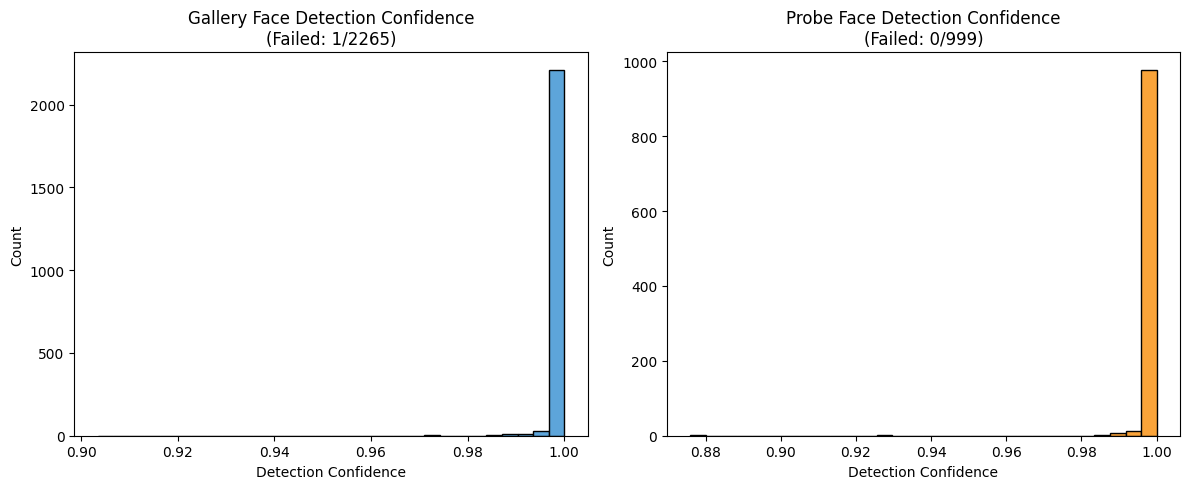


Gallery mean confidence (detected faces): 0.9995
Probe mean confidence (detected faces): 0.9994


In [17]:
# Analyze the distribution of MTCNN confidence scores
import matplotlib.pyplot as plt

# Convert to arrays so we can use boolean indexing
gallery_confs_array = np.array(gallery_confs)
probe_confs_array = np.array(probe_confs)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gallery confidence distribution
ax1 = axes[0]
# Filter out the 0.0 fallback entries as those aren't real detections
ax1.hist(gallery_confs_array[gallery_confs_array > 0], bins=30, color='#5DA5DA', edgecolor='black')
ax1.set_xlabel('Detection Confidence')
ax1.set_ylabel('Count')
ax1.set_title(f'Gallery Face Detection Confidence\n(Failed: {gallery_fails}/{len(gallery_confs)})')

# Probe confidence distribution
ax2 = axes[1]
ax2.hist(probe_confs_array[probe_confs_array > 0], bins=30, color='#FAA43A', edgecolor='black')
ax2.set_xlabel('Detection Confidence')
ax2.set_ylabel('Count')
ax2.set_title(f'Probe Face Detection Confidence\n(Failed: {probe_fails}/{len(probe_confs)})')

plt.tight_layout()
plt.savefig(figures_dir / "mtcnn_confidence_distribution.png", dpi=150)
plt.show()

# Mean confidence only over successful detections 
# Failures are excluded since they're always 0.0
print(f"\nGallery mean confidence (detected faces): {gallery_confs_array[gallery_confs_array > 0].mean():.4f}")
print(f"Probe mean confidence (detected faces): {probe_confs_array[probe_confs_array > 0].mean():.4f}")

In [18]:
# Update task2_results to include the MTCNN findings
task2_results = {
    "bruteforce": {"top1": bf_top1, "top5": bf_top5, "time_ms": bf_time},
    "hnsw": {"top1": hnsw_top1, "top5": hnsw_top5, "time_ms": hnsw_time},
    "mtcnn": {
        "top1": mtcnn_top1, 
        "top5": mtcnn_top5,
        "gallery_fails": gallery_fails,
        "probe_fails": probe_fails,
        "gallery_mean_conf": float(gallery_confs_array[gallery_confs_array > 0].mean()),
        "probe_mean_conf": float(probe_confs_array[probe_confs_array > 0].mean())
    },
    "baseline": {"top1": 0.7087, "top5": 0.8358},
    "n_gallery": 2265,
    "dim": 512
}

results_path = BASE_DIR / "analysis" / "task2_results.pkl"
with open(results_path, "wb") as f:
    pickle.dump(task2_results, f)

print(f"Results saved to: {results_path}")

Results saved to: /Users/radinabakalov/ironclad-radinabakalov/analysis/task2_results.pkl
